In [1]:
## Libraries, modules
import soundfile as sf
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import hann
import cv2
from skimage.feature import peak_local_max


## Recording file
rec_filename = "000_1.392_seq.flac" # "001_235.717_seq.flac"


In [2]:
## Functions
# Spectrogram bandpass filter
def spec_bandpass(spec, f_max, f_bins, f_low, f_high):
    f_bl = int(f_low/f_max*f_bins) # Low frequency bin
    f_bh = int(f_high/f_max*f_bins) # High frequency bin
    return spec[f_bl:f_bh,:]

# Measure time and frequency of detected signals (after correlation and local maxima search)
def meas_time_freq(t_min, t_max, t_bins, local_maxima):
    times = np.linspace(t_min, t_max, t_bins)[local_maxima[:, 1]]  # Time values from indices
    freqs = np.linspace(f_min, f_max, f_bins)[local_maxima[:, 0]]  # Frequency values from indices
    return times, freqs

# Add detected signals to list
def signals2list(signal_type, signals_detected, detected_times, detected_freqs, corr_values):
    for i in range(len(detected_times)):
        signals_detected.append([
            signal_type,  # Signal type
            round(detected_times[i], 2),  # Time rounded to 2 decimal places
            int(detected_freqs[i]),  # Frequency as an integer
            round(corr_values[i], 2)  # Correlation value rounded to 2 decimal places
        ])
    return signals_detected

# Blank the spectrogram based on local maxima
def blank_spectrogram(blanked_spectrogram, local_maxima, t_start_corr, t_end_corr, signal, t_bins):
    for local_max in local_maxima:
        signal_time_width = signal.shape[1] # Calculate signal width (time samples)
        t_idx = local_max[1]  # Time index where occurs (lower left corner)        
        t_start_idx = max(0, t_idx - t_start_corr) # Start time index
        t_end_idx = min(t_bins, t_idx + signal_time_width + t_end_corr) # End time index
        blanked_spectrogram[:, t_start_idx:t_end_idx] = np.min(recording_crop) # Blank spectrogram in signal time window
    return blanked_spectrogram

# Remove short detections (noise when detecting tone signals)
def remove_short_detections(arr, min_ones):
    result = arr.copy()
    i = 0
    while i < len(result):
        if result[i] == 1:  # Found the start of a sequence of 1s
            start = i
            while i < len(result) and result[i] == 1:  # Find the end of this sequence
                i += 1
            end = i
            if end - start < min_ones:  # If the length of the sequence is shorter than min_ones, set to 0
                for j in range(start, end):
                    result[j] = 0
        else:
            i += 1    
    return result

# Find tone signals based on timing
def find_tone_signals(bin_list, tones_freq_med):
    tone_signals = []
    start_idx = None
    for i, num in enumerate(bin_list):  # Go through detection array
        if num > 0:
            if start_idx is None:  # Beginning of a new sequence of 1s
                start_idx = i
        elif num == 0 and start_idx is not None:  # End the sequence when we hit a 0 after detecting 1s
            tone_signals.append((start_idx, i - 1, tones_freq_med[start_idx]))  # Add median value as third column
            start_idx = None    
    if start_idx is not None:  # If we end with a sequence of 1s and it's still open, close it
        tone_signals.append((start_idx, len(bin_list) - 1, tones_freq_med[start_idx]))  # Add median value as third column
    return tone_signals

# Monster function to translate tones
def translate_tones(tone_signals):
    tones_list = [] # List with final output
    i = 0 # Initialize row index
    while i < len(tone_signals):
        duration_samples = tone_signals[i][1] - tone_signals[i][0] # Duration of each sequence, in samples
        row = [tone_signals[i][0], tone_signals[i][1], duration_samples, "", ""] # Add empty 5th column for frequency
        if (duration_samples > 150): # Tone A is usually ~141 samples, so longer tones mean that A & B or A & C are too close to each other
            raise ValueError("Check for possible A+B or A+C.")
        elif (duration_samples > 130): # Tone A is usually ~141 samples
            row[3] = "A"
            row[4] = tone_signals[i][2] # Frequency sample
        elif (duration_samples > 90): # Tone B is usually ~83 samples, so longer tones mean that B & C are too close to each other
            raise ValueError("Check for possible B+C.")
        elif (duration_samples > 70): # Tone B is usually > 80 samples
            row[3] = "B"
            row[4] = tone_signals[i][2] # Frequency sample
        elif (duration_samples > 25): # Tone C is made of two tones, the first is usually > 33 samples
            if i + 1 < len(tone_signals): # Check if there is a next row
                next_duration_samples = tone_signals[i + 1][1] - tone_signals[i + 1][0]
                if (next_duration_samples < 20):  # The second tone is usually < 17 samples
                    tones_list.append([tone_signals[i][0], tone_signals[i + 1][1], (tone_signals[i + 1][1] - tone_signals[i][0]), "C", tone_signals[i][2]])  # Merge rows and add "C" label
                    i += 2 # Skip the next row as it was merged with the current one
                    continue # Skip current row because it's merged with the next row
                else:
                    raise ValueError("C tone only partially detected (missing 2nd half).")
            else:
                raise ValueError("C tone only partially detected (end of tone_signals).")
        else:
            raise ValueError("C tone only partially detected (missing 1st half).")
        
        tones_list.append(row)
        i += 1 # Move to the next row

    return tones_list

In [3]:
## Read full audio recording
audio_rec, fs = sf.read("./signal_sequences/"+rec_filename)
data = audio_rec[:,0] + audio_rec[:,0] # LSumming the two doesn't improve SNR, but doesn't hurt either.

## Initialize list of detected signals
signals_detected = [
    ["Signal Type", "Time (s)", "Frequency (Hz)", "Correlation Value"]
]

In [4]:
## Generate Spectrogram (2D FFT)
# Parameters
win_size = 2048  # Window size, 1024 to 4096 are ideal
hop_size = int(win_size*0.5)  # Overlap
fs = 48000  # Your sampling frequency
win = hann(win_size)

# Spectrogram
SFT = ShortTimeFFT(win, hop=hop_size, fs=fs) # Initialize ShortTimeFFT
Sx2 = SFT.spectrogram(data) # Compute the spectrogram (absolute square of STFT)
Sx2[Sx2 == 0] = np.min(Sx2[np.nonzero(Sx2)]) # Substitute zeros with the minimum non-zero value to avoid log(0)
Sx2_dB = 10 * np.log10(Sx2) # Convert spectrogram to dB
t_min, t_max, f_min, f_max = SFT.extent(len(audio_rec), center_bins=True) # Get frequency and time boundaries
f_bins, t_bins = Sx2.shape # Get the number of frequency and time bins

In [5]:
## Crop spectrogram to avoid high frequency aliased signals
# Frequency range
f_low = 0  # Hz
f_high = 15000  # Hz
f_0 = int(f_low * f_bins / (f_max - f_min))
f_1 = int(f_high * f_bins / (f_max - f_min))

# Time range
t_start = t_min
t_end = t_max
t_0 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_start)
t_1 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_end)

# Crop the spectrogram to the selected frequency and time ranges
recording_crop = Sx2_dB[f_0:f_1, t_0:t_1].astype(np.float32)

In [6]:
## Blank first and last 9.9 s, they shouldn't contain any signal
recording_crop[:, 0:int(fs/2048*2*9.9)] = np.min(recording_crop)
recording_crop[:, -int(fs/2048*2*9.9):] = np.min(recording_crop)

In [7]:
## Detect EOL signal
# Signal detection
signal = np.genfromtxt('signal_samples/end_signal_48k-2048.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=1, threshold_abs=0.4) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
corr_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("X", signals_detected, detected_times, detected_freqs, corr_values) # Add to list of detected signals

# Blank spectrogram
t_start_corr = 577 # Correction to signal start time (assumes 2048 FFT samples)
t_end_corr = 100 # Correction to signal end time (assumes 2048 FFT samples)
recording_crop_blank_EOL = blank_spectrogram(recording_crop.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins)

In [8]:
## Detect G signal
# Signal detection
signal = np.genfromtxt('signal_samples/G_signal_48k-2048.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_EOL, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=1, threshold_abs=0.4) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
corr_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("G", signals_detected, detected_times, detected_freqs, corr_values) # Add to list of detected signals

# Blank spectrogram
t_start_corr = 0 # Correction to signal start time (assumes 2048 FFT samples)
t_end_corr = 0 # Correction to signal end time (assumes 2048 FFT samples)
recording_crop_blank_G = blank_spectrogram(recording_crop_blank_EOL.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins)

In [9]:
## Detect F signal
# Signal detection
signal = np.genfromtxt('signal_samples/F_signal_48k-2048.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_G, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=1, threshold_abs=0.35) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
corr_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("F", signals_detected, detected_times, detected_freqs, corr_values) # Add to list of detected signals

# Blank spectrogram
t_start_corr = 0 # Correction to signal start time (assumes 2048 FFT samples)
t_end_corr = 0 # Correction to signal end time (assumes 2048 FFT samples)
recording_crop_blank_F = blank_spectrogram(recording_crop_blank_G.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins)

In [10]:
## Detect E signal
# Signal detection
signal = np.genfromtxt('signal_samples/E_signal_48k-2048.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_F, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=1, threshold_abs=0.35) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
corr_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("E", signals_detected, detected_times, detected_freqs, corr_values) # Add to list of detected signals

# Blank spectrogram
t_start_corr = 18 # Correction to signal start time (assumes 2048 FFT samples)
t_end_corr = 0 # Correction to signal end time (assumes 2048 FFT samples)
recording_crop_blank_E = blank_spectrogram(recording_crop_blank_F.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins)

In [11]:
## Detect D signal
# Signal detection
signal = np.genfromtxt('signal_samples/D_signal_48k-2048.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_E, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=1, threshold_abs=0.3) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
corr_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("D", signals_detected, detected_times, detected_freqs, corr_values) # Add to list of detected signals

# Blank spectrogram
t_start_corr = 0 # Correction to signal start time (assumes 2048 FFT samples)
t_end_corr = 63 # Correction to signal end time (assumes 2048 FFT samples)
recording_crop_blank_D = blank_spectrogram(recording_crop_blank_E.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins)

In [12]:
## Measure background noise level
noise = spec_bandpass(Sx2_dB, f_max, f_bins, 6300, 6700) # Extract noise band
noise_mean = np.mean(noise) # Noise mean level
noise_std = np.std(noise) # Noise standard deviation

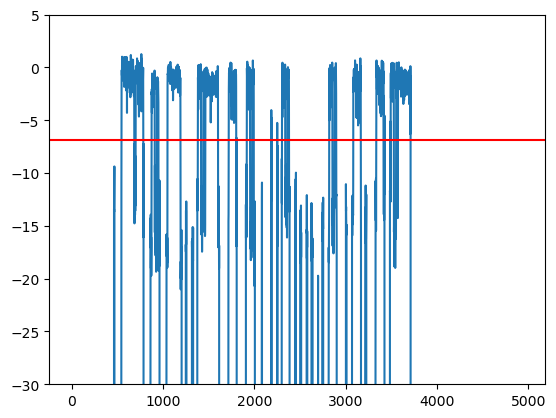

In [13]:
## Measure signal level in strong "tone" band
f_low = 6600
f_high = 7700
sig_bandpass = spec_bandpass(recording_crop_blank_D, f_max, f_bins, f_low, f_high)
sig_level = np.max(sig_bandpass, axis=0)

std_num = 2.25 # Number of standard deviations to use for thresholding
plt.plot(sig_level)
plt.axhline(y = noise_mean + noise_std*2.25, color = 'r', linestyle = '-')
plt.ylim(-30, 5)
plt.show()

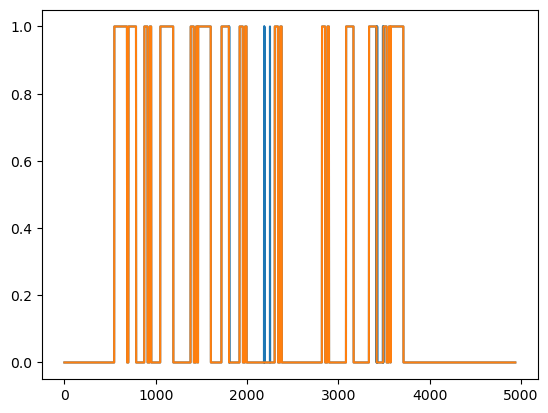

In [14]:
## Create "detection" array
std_num = 2.25 # Number of standard deviations to use for thresholding
threshold = noise_mean + noise_std*std_num # Threshold level to detect a signal
above_threshold = (sig_level > threshold).astype(int) # Array of detections (1) and non-detections (0)
min_ones = int(fs/win_size*2*0.2) # 0.2 seconds, the shortest portion of signal C is 0.38 s long
sig_detected = remove_short_detections(above_threshold, min_ones)

plt.plot(above_threshold)
plt.plot(sig_detected)
plt.show()

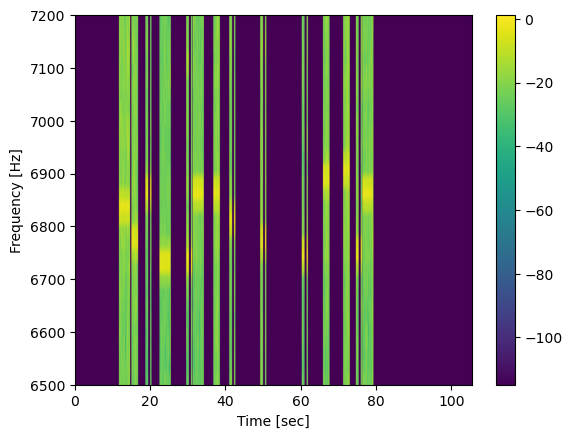

In [15]:
## Blanking of noise sections based on previous detections, then bandpass to low frequency strong tone.
# Cropping based on sig_detected, applied to the original cropped spectrogram
recording_crop_blank_tones = recording_crop.copy()
recording_crop_blank_tones[:, np.where(sig_detected == 0)[0]] = np.min(recording_crop)

# First bandpass filter (wide)
f_low_1 = 6500
f_high_1 = 7200
recording_crop_blank_tones_bp1 = spec_bandpass(recording_crop_blank_tones, f_max, f_bins, f_low_1, f_high_1)

# Plot 'cropped' spectrogram  (in dB)
plt.imshow(recording_crop_blank_tones_bp1, origin='lower', aspect='auto', extent=[t_min, t_max, f_low_1, f_high_1])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

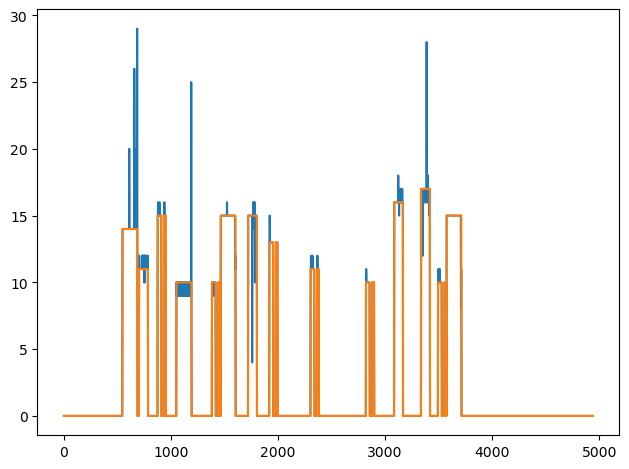

In [16]:
## Find local maxima for each tone (frequency sample), 1st pass
# Local maxima, this is often noisy
tones_local_max = np.argmax(recording_crop_blank_tones_bp1, axis=0)

# Find indices at the end tone segments
det_idx = np.where(sig_detected == 1)[0] # Find the indices where a tone is s detected
tone_segm_boundaries = np.where(np.diff(det_idx) > 1)[0] + 1 # Find the boundaries where the difference is greater than 1
tone_segm_boundaries = np.concatenate(([0], tone_segm_boundaries, [len(det_idx)])) # Add the first and last index to define the tone segments

# Calculate the median of tones_local_max for each tone segment
medians = []
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    medians.append(np.median(tones_local_max[segment]))

# Initialize an array for tones_local_max_med, add the corresponding median for each segment (this works as a filter)
tones_freq_med = np.copy(tones_local_max)
segment_start = 0
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    median_value = medians[i]
    tones_freq_med[segment] = median_value

# Plot both original and modified (median) tones
plt.plot(tones_local_max)
plt.plot(tones_freq_med)
plt.tight_layout()
plt.show()

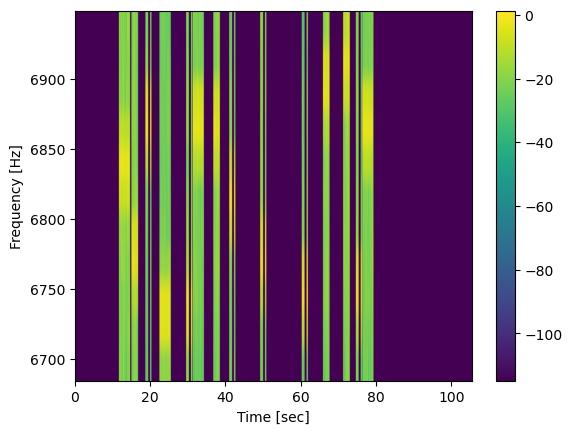

In [17]:
## Determine min/max tone frequencies, then run second bandpass (narrow)
margin = 50 # Frequency margin below and above tones
f_low_2 = np.min(tones_freq_med[tones_freq_med != 0])*fs/win_size + f_low_1 - margin
f_high_2 = np.max(tones_freq_med)*fs/win_size + f_low_1 + margin
recording_crop_blank_tones_bp2 = spec_bandpass(recording_crop_blank_tones, f_max, f_bins, f_low_2, f_high_2)

# Plot 'cropped' spectrogram  (in dB)
plt.imshow(recording_crop_blank_tones_bp2, origin='lower', aspect='auto', extent=[t_min, t_max, f_low_2, f_high_2])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

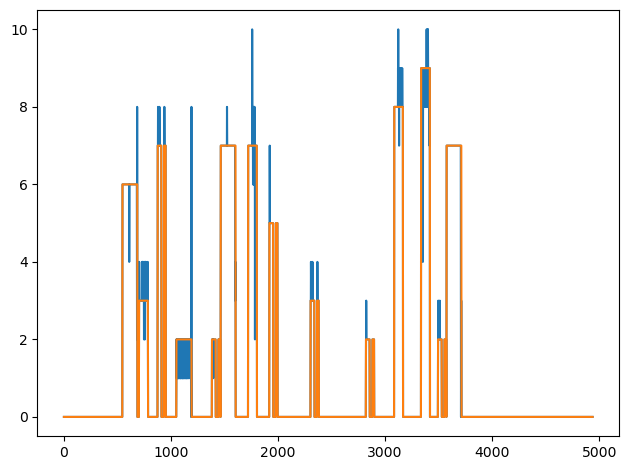

In [18]:
## Find local maxima for each tone (frequency sample), 2nd pass
# Local maxima, this is often noisy
tones_local_max = np.argmax(recording_crop_blank_tones_bp2, axis=0)

# Find indices nd tone segments
det_idx = np.where(sig_detected == 1)[0] # Find the indices where a tone is s detected
tone_segm_boundaries = np.where(np.diff(det_idx) > 1)[0] + 1 # Find the boundaries where the difference is greater than 1
tone_segm_boundaries = np.concatenate(([0], tone_segm_boundaries, [len(det_idx)])) # Add the first and last index to define the tone segments

# Calculate the median of tones_local_max for each tone segment
medians = []
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    medians.append(np.median(tones_local_max[segment]))

# Initialize an array for tones_local_max_med, add the corresponding median for each segment (this works as a filter)
tones_freq_med = np.copy(tones_local_max)
segment_start = 0
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    median_value = medians[i]
    tones_freq_med[segment] = median_value

# Plot both original and modified (median) tones
plt.plot(tones_local_max)
plt.plot(tones_freq_med)
plt.tight_layout()
plt.show()

In [19]:
## Detect tones
# Find tone signals (as sequences of values above 0)
tone_signals = find_tone_signals(sig_detected, tones_freq_med)

# Detect which tones occur
try:
    tones_list = translate_tones(tone_signals)
except ValueError as e:
    print(f"Error: {e}")

# Convert to time and frequency values
tone_type = np.array(tones_list)[:, 3]
tone_times = np.array([row[0] for row in tones_list])
tone_freqs = np.array([row[4] for row in tones_list])
detected_times = np.linspace(t_min, t_max, t_bins)[tone_times] # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[tone_freqs] + f_low_2  # Frequency values from indices, corrected for previous bandpass

# Calculate length metric
length_metric = np.zeros(len(tones_list))
length_samples = np.array([row[2] for row in tones_list]) # Length of tones (in # samples), it shouldn't differ much from 'standard' values
for t in range(len(length_samples)):
    if tone_type[t] == "A":
        length_metric[t] = (1 - (np.abs(length_samples[t] - 141) / 141))  # Tone A
    if tone_type[t] == "B":
        length_metric[t] = (1 - (np.abs(length_samples[t] - 83) / 83))  # Tone B
    if tone_type[t] == "C":
        length_metric[t] = (1 - (np.abs(length_samples[t] - 75) / 75))  # Tone C

# Add to list of detected signals
for i in range(len(detected_times)):
    signals_detected.append([
        tone_type[i], # Signal type
        round(detected_times[i], 2), # Time rounded to 2 decimal places
        int(detected_freqs[i]), # Frequency as an integer
        round(length_metric[i], 2) # Length metric as an integer
    ])

In [20]:
## Final signal sorting and printout
# Sort list based on time
signals_detected = [signals_detected[0]] + sorted(signals_detected[1:], key=lambda x: x[1])

# Print the detected signals
for row in signals_detected:
    print(row)

['Signal Type', 'Time (s)', 'Frequency (Hz)', 'Correlation Value']
['D', 10.0, 4469, 0.52]
['A', 11.64, 6813, 0.99]
['B', 14.95, 6743, 1.0]
['D', 16.8, 4492, 0.52]
['C', 18.66, 6836, 1.0]
['D', 20.54, 4375, 1.0]
['A', 22.39, 6719, 1.0]
['F', 25.7, 10052, 0.65]
['E', 27.22, 7542, 0.51]
['F', 28.39, 10005, 0.7]
['C', 29.48, 6719, 0.99]
['A', 31.23, 6836, 0.98]
['G', 34.47, 7425, 1.0]
['B', 36.69, 6836, 0.98]
['G', 38.57, 7542, 0.57]
['C', 40.91, 6789, 0.99]
['D', 42.81, 4445, 0.6]
['G', 44.48, 7589, 0.44]
['E', 47.1, 7612, 0.54]
['F', 48.11, 9865, 0.78]
['C', 49.13, 6743, 0.99]
['E', 51.31, 7565, 0.52]
['F', 52.42, 9912, 0.87]
['E', 54.02, 7777, 1.0]
['F', 55.06, 9841, 1.0]
['E', 56.68, 7777, 0.84]
['F', 57.58, 9794, 0.79]
['E', 59.16, 7800, 0.82]
['C', 60.16, 6719, 0.99]
['G', 61.93, 7448, 0.68]
['E', 64.62, 7706, 0.72]
['B', 65.79, 6860, 0.98]
['F', 67.61, 9771, 0.74]
['G', 68.85, 7354, 0.7]
['B', 71.15, 6883, 0.99]
['E', 73.48, 7777, 0.75]
['C', 74.52, 6719, 0.99]
['A', 76.23, 6836, 0